In [7]:
import matplotlib.pyplot as plt
import pandas as pd

selected_results_fb15k_no_pref = {
    "random": "../results/fb15k_10_0.001_random_test_positive_1738248353/all_metrics.txt",
    "default-p": "../results/fb15k_10_0.001_default_test_positive_1738847753/all_metrics_test_positive.txt"
}

selected_results_fb15k_pos = {
    "greedy-p": "/home/daniel/projects/quack/results/fb15k_10_0.001_greedy_test_positive_1738676398/all_metrics_test_positive.txt",
    "cosine-p": "../results/fb15k_10_0.001_cosine_0.1_test_positive_1738673171/all_metrics_test_positive.txt",
    # "neural-kldiv-p": "../results/fb15k_10_0.001_ltr_0.0001_positive_1739493134/all_metrics_test_positive.txt",
    "neural-kldiv-p": "../results/fb15k_10_0.001_ltr_0.001_test_positive_1740656535/all_metrics_test_positive.txt",
    "neural-lc-p": "../results/fb15k_10_0.001_ltr_0.0001_positive_1739562177/all_metrics_test_positive.txt"
}

selected_results_fb15k_neg = {
    "greedy-n": "/home/daniel/projects/quack/results/fb15k_10_0.001_greedy_test_negative_1738674178/all_metrics_test_negative.txt",
    "cosine-n": "../results/fb15k_10_0.001_cosine_0.9_test_negative_1738673179/all_metrics_test_negative.txt",
    # "neural-kldiv-n": "../results/fb15k_10_0.001_ltr_0.0001_positive_1739493134/all_metrics_test_negative.txt",
    "neural-kldiv-n": "../results/fb15k_10_0.001_ltr_0.001_test_negative_1740732882/all_metrics_test_negative.txt",
    "neural-lc-n": "../results/fb15k_10_0.001_ltr_0.0001_positive_1739562177/all_metrics_test_negative.txt",
}

selected_results_fb15k = {**selected_results_fb15k_no_pref, **selected_results_fb15k_pos, **selected_results_fb15k_neg}

def process_files(file_dict, metric_name):
    data = []

    for method, file in file_dict.items():
        metrics = {}
        metrics["method"] = method
        all_values = []
        with open(file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 4:
                    continue  # Ignore malformed lines
                _, query_type, metric, value = parts
                value = float(value)
                if metric == f"{metric_name}:":
                    all_values.append(value)
                    metrics[f"{query_type}"] = f"{value * 100:.2f}"

        metrics["avg"] = f"{pd.Series(all_values).mean() * 100:.2f}"
        data.append(metrics)

    # Convert list of dicts to a DataFrame
    df = pd.DataFrame(data)
    return df

In [8]:
df_pa = process_files(selected_results_fb15k, "cumulative_pairwise_accuracy")
print("Cumulative Pairwise Accuracy")
print(df_pa.to_latex(index=False))
# df_pa

Cumulative Pairwise Accuracy
\begin{tabular}{llllllllllllllll}
\toprule
method & 1p & 2p & 3p & 2i & 3i & ip & pi & 2in & 3in & inp & pin & pni & 2u-DNF & up-DNF & avg \\
\midrule
random & 12.12 & 21.57 & 20.78 & 12.90 & 9.83 & 21.48 & 16.78 & 21.21 & 17.62 & 19.50 & 22.15 & 25.16 & 22.29 & 22.08 & 18.96 \\
default-p & 53.95 & 50.05 & 50.05 & 52.55 & 51.20 & 46.41 & 49.96 & 54.74 & 52.42 & 48.88 & 51.96 & 54.64 & 55.34 & 52.26 & 51.74 \\
greedy-p & 70.88 & 61.03 & 60.47 & 64.75 & 65.68 & 59.22 & 60.55 & 63.17 & 62.59 & 61.64 & 61.95 & 63.33 & 62.86 & 60.85 & 62.78 \\
cosine-p & 83.23 & 80.11 & 80.71 & 80.16 & 79.84 & 78.23 & 77.59 & 77.74 & 77.43 & 81.92 & 80.45 & 78.21 & 78.68 & 80.44 & 79.62 \\
neural-kldiv-p & 63.76 & 61.88 & 62.31 & 58.91 & 57.30 & 64.58 & 60.17 & 62.85 & 59.16 & 60.74 & 61.71 & 62.39 & 62.13 & 60.87 & 61.34 \\
neural-lc-p & 69.90 & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & 69.90 \\
greedy-n & 76.53 & 74.36 & 73.70 & 75.29 & 73.6

In [9]:
df_mrr = process_files(selected_results_fb15k, "cumulative_mrr_hard_delta")
print("Relative MRR Delta")
print(df_mrr.to_latex(index=False))
# df_mrr

Relative MRR Delta
\begin{tabular}{llllllllllllllll}
\toprule
method & 1p & 2p & 3p & 2i & 3i & ip & pi & 2in & 3in & inp & pin & pni & 2u-DNF & up-DNF & avg \\
\midrule
random & -99.64 & -98.74 & -98.80 & -99.85 & -99.85 & -98.12 & -98.93 & -99.17 & -99.08 & -97.54 & -98.01 & -93.41 & -99.61 & -99.35 & -98.58 \\
default-p & 0.00 & 0.00 & 0.00 & 0.00 & 0.00 & 0.00 & 0.00 & 0.00 & 0.00 & 0.00 & 0.00 & 0.00 & 0.00 & 0.00 & 0.00 \\
greedy-p & 171.32 & 928.09 & 1028.32 & 47.72 & 45.29 & 1816.96 & 1060.87 & 745.85 & 727.15 & 1550.25 & 1353.55 & 4098.87 & 153.40 & 339.99 & 1004.83 \\
cosine-p & -13.41 & 548.42 & 388.93 & -52.16 & -48.38 & 1185.15 & 417.86 & 202.32 & 225.25 & 658.26 & 538.90 & 1613.78 & -20.36 & 60.10 & 407.47 \\
neural-kldiv-p & 0.41 & 116.54 & 69.93 & 0.22 & 0.09 & 253.94 & 125.21 & 36.37 & 27.08 & 75.98 & 75.79 & 0.55 & -0.04 & 9.71 & 56.56 \\
neural-lc-p & 5.14 & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & 5.14 \\
greedy-n & -54.45 & -40.

In [10]:
selected_results_fb15k237 = {
    "random": "../results/fb15k237_10_0.0002_random_test_positive_1738320306/all_metrics_test_positive.txt",
    "cosine-p": "../results/fb15k237_10_0.0002_cosine_0.1_test_positive_1738455153/all_metrics_test_positive.txt",
    "cosine-n": "../results/fb15k237_10_0.0002_cosine_0.9_test_negative_1738459772/all_metrics_test_negative.txt",
}

In [11]:
df_pa = process_files(selected_results_fb15k237, "cumulative_pairwise_accuracy")
print("Cumulative Pairwise Accuracy")
print(df_pa.to_latex(index=False))

Cumulative Pairwise Accuracy
\begin{tabular}{llllllllllllllll}
\toprule
method & 1p & 2p & 3p & 2i & 3i & ip & pi & 2in & 3in & inp & pin & pni & 2u-DNF & up-DNF & avg \\
\midrule
random & 33.02 & 44.26 & 49.08 & 33.54 & 29.89 & 42.49 & 38.03 & 40.99 & 37.60 & 46.72 & 45.36 & 43.28 & 40.98 & 46.13 & 40.81 \\
cosine-p & 84.83 & 82.92 & 83.19 & 80.61 & 77.08 & 81.45 & 80.30 & 80.22 & 79.58 & 83.24 & 82.00 & 80.76 & 81.38 & 82.19 & 81.41 \\
cosine-n & 72.19 & 72.04 & 71.72 & 63.80 & 59.74 & 72.56 & 66.97 & 73.11 & 66.04 & 70.66 & 71.50 & 72.75 & 72.92 & 70.32 & 69.74 \\
\bottomrule
\end{tabular}



In [12]:
df_mrr = process_files(selected_results_fb15k237, "cumulative_mrr_hard_delta")
print("Relative MRR Delta")
print(df_mrr.to_latex(index=False))

Relative MRR Delta
\begin{tabular}{llllllllllllllll}
\toprule
method & 1p & 2p & 3p & 2i & 3i & ip & pi & 2in & 3in & inp & pin & pni & 2u-DNF & up-DNF & avg \\
\midrule
random & -98.14 & -95.37 & -95.46 & -99.39 & -99.60 & -96.96 & -98.62 & -97.28 & -98.57 & -94.63 & -95.10 & -85.71 & -97.51 & -96.15 & -96.32 \\
cosine-p & 377.94 & 1214.44 & 777.76 & 41.82 & 6.57 & 749.08 & 249.20 & 505.69 & 480.51 & 996.82 & 1174.60 & 2759.52 & 361.01 & 684.97 & 741.42 \\
cosine-n & -20.59 & -28.96 & -28.02 & -13.60 & -17.21 & -29.40 & -23.67 & -21.81 & -17.75 & -31.34 & -28.67 & -24.06 & -15.63 & -23.02 & -23.12 \\
\bottomrule
\end{tabular}



In [34]:
def plot_pa_mrr(df_pa, df_mrr):
    df_pa["1p"] = df_pa["1p"].astype(float)
    df_mrr["1p"] = df_mrr["1p"].astype(float)

    fig, ax = plt.subplots()
    ax.scatter(df_pa["1p"], df_mrr["1p"])
    for i, txt in enumerate(df_pa["method"]):
        ax.annotate(txt, (df_pa["1p"][i], df_mrr["1p"][i]))
    plt.xlabel("Pairwise Accuracy")
    plt.ylabel("$\Delta$MRR")
    plt.grid()

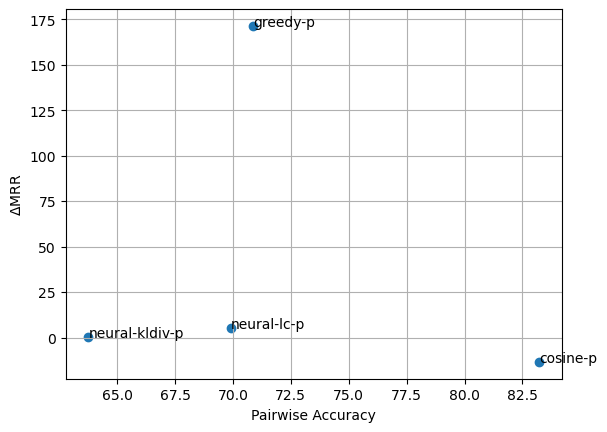

In [37]:
df_pa = process_files(selected_results_fb15k_pos, "cumulative_pairwise_accuracy")
df_mrr = process_files(selected_results_fb15k_pos, "cumulative_mrr_hard_delta")
plot_pa_mrr(df_pa, df_mrr)

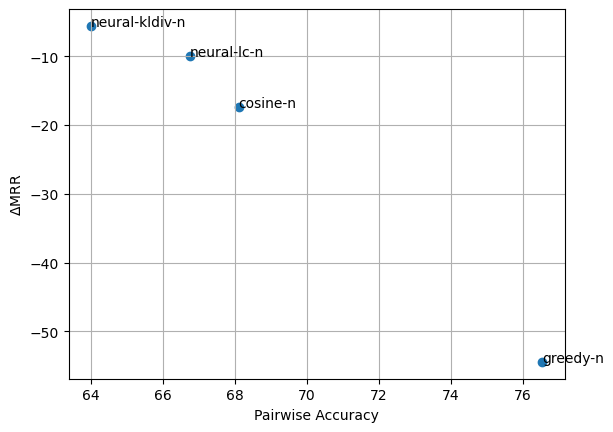

In [38]:
df_pa = process_files(selected_results_fb15k_neg, "cumulative_pairwise_accuracy")
df_mrr = process_files(selected_results_fb15k_neg, "cumulative_mrr_hard_delta")
plot_pa_mrr(df_pa, df_mrr)